now for report_pipeline.py

1. We'll run the inference and get the plots for all individual models and overall report
2. finally We create a report table df1 with these columns:
    * Ground Truth (this will be taken from spnwer)
    * Does it have airborne_status (Ground_truth)
    * Does it have remote_override_flag (ground_truth)
    * SL_answer
    * SL_conf
    * Does_match with ground_truth with more than 98% conf (if yes, level 1 cleared)
         - ex - If SL AGV (fly or no fly) matches with ground_truth AGV and level 1 check complete
    * Does it mathces override_flag or airborne_status (as Sl will divide into 7 classfication, so we'll know if it is flaged with these) (if yes level 2 is cleared)
        - ex - if SL AGV (fly) means Airbone_status(from ground truth) should be true, if not level 2 fails. same for robotic_arm in overide case.
    * USL_answer
    * USL_conf
    * Does_match with ground_truth with more than 95% conf (if yes, level 3 cleared)
    * Level_cleared (1 or 2 or 3)
3. Another table df2 where I run multiple runs with different combinations of models (We'll be specfy which model we are choosing for SL, usl, RL, at start of every run)
    * USL_model
    * SL_model
    * RL_model
    * Points_level_cleared (if all 3 level is cleared than 3 points, if only 2 level are cleared than only 2 points and same for 1, so max point is 30, 3x10 10, locations)
    * Total rewards collected by RL
    * Time taken by RL model to complete (this will be)
4. We have to see (visualize) the arrow navigating rl env.
5. Rows will be 10 locations which is set by spanwer for df1, it also collect 100 rows and 100 images


In [ ]:
"""
File: train_all.py
This script serves as the master execution hub for the entire project, orchestrating
the training pipelines for Supervised Learning (SL), Unsupervised Learning (USL),
and Reinforcement Learning (RL) sequentially.
"""

from pathlib import Path
from mapping import map_csv, map_imgs
from SL_training.train_sl_models import SLTraining
from USL_training.train_usl_models import USLTraining
from RL_training.train_rl_models import RLTraining


if __name__ == "__main__":

    # CREATING FOLDERS
    IMG_PATH = "DATA/DATASET"
    CSV_PATH = "DATA/SENSOR_STATS.csv"
    PLOT_PATH = "PLOTS/"
    MODEL_PATH = "MODELS/"
    SEED = 47
    if not Path(CSV_PATH).exists(): map_csv()
    if not Path(IMG_PATH).exists(): map_imgs()
    Path(PLOT_PATH).mkdir(parents=True, exist_ok=True) # For All Plots
    Path(MODEL_PATH).mkdir(parents=True, exist_ok=True) # For All Models

    # SUPERVISED LEARNING PIPELINE
    print("SUPERVISED LEARNING MODELS TRAINING......")
    sl_trainer = SLTraining(seed=SEED, data_path=CSV_PATH, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
    sl_trainer.train_sl_models()
    print("SUPERVISED LEARNING MODELS TRAINING COMPLETE\n")

    # UNSUPERVISED LEARNING PIPELINE
    print("UNSUPERVISED LEARNING MODELS TRAINING......")
    #usl_trainer = USLTraining(seed=SEED, data_dir=IMG_PATH, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
    #usl_trainer.train_usl_models()
    print("UNSUPERVISED LEARNING MODELS TRAINING COMPLETE\n")

    # REINFORCEMENT LEARNING PIPELINE
    print("REINFORCEMENT LEARNING MODELS TRAINING......")
    #rl_trainer = RLTraining(episodes=5000, seed=SEED, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
    #rl_trainer.train_rl_models()
    print("REINFORCEMENT LEARNING MODELS TRAINING COMPLETE")


In [13]:
import pandas as pd

df1 = pd.read_csv("report_df1.csv")

df1.head (10)

,Location_ID,Ground_Truth,Airborne_(GT),Override_(GT),SL_Answer,SL_Conf,L1_Cleared,L2_Cleared,USL_Answer,USL_Conf,L3_Cleared,Level_Cleared
0,0,plc_controller,False,False,plc_controller,0.999,True,True,drone,1.000,False,2
1,1,drone,True,False,drone_fly,0.993,True,True,drone,1.000,True,3
2,2,drone,True,False,drone_fly,0.997,True,True,drone,1.000,True,3
3,3,drone,True,False,drone_fly,0.991,True,True,drone,1.000,True,3
4,4,plc_controller,False,False,plc_controller,0.998,True,True,drone,1.000,False,2
5,5,cnc_machine,False,False,cnc_machine,0.998,True,True,drone,1.000,False,2
6,6,robotic_arm,False,True,robotic_arm_non_override,0.996,True,True,drone,1.000,False,2
7,7,drone,True,False,drone_fly,0.997,True,True,drone,1.000,True,3
8,8,cnc_machine,False,False,cnc_machine,0.999,True,True,drone,0.996,False,2
9,9,agv_unit,True,False,agv_unit_non_fly,0.983,True,True,drone,1.000,False,2


In [5]:
df2 = pd.read_csv("report_df2.csv")

df2.head (10)

,USL_Model,SL_Model,RL_Model,Points_Level_Cleared,Total_Rewards_Collected,Time_Taken_RL
0,GMM,Random Forest,Q-Learning,2,180.06,106.53
1,DEC,SVM,SARSA,0,60.27,96.46


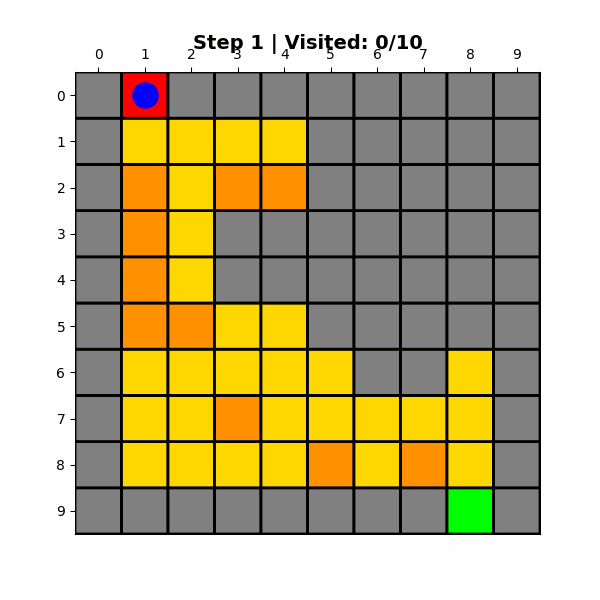

In [10]:
from IPython.display import Image

# Display the GIF
Image(filename='rl_agent_navigation.gif')

In [ ]:
def parse_label(label):
    if label.startswith("robotic_arm"):
        base = "robotic_arm"
        attr_string = label[12:] 
    elif label.startswith("agv_unit"):
        base = "agv_unit"
        attr_string = label[9:]
    else:
        parts = label.split("_")
        base = parts[0]
        attr_string = "_".join(parts[1:])
    #attrs = set(attr_string.split("_")) if attr_string else set()
    return base, attr_string

parse_label('robotic_arm_non_fly')


('robotic_arm', 'non_fly')

In [ ]:
    is_non = "non" in sl_attrs
    

    air_match = (not is_non) == bool(air)
    override_match = (not is_non) == bool(override)
    
    # L2 is True if both statuses align with your specific logic points
    l2 = air_match and override_match